# Demo 2a: Literary Detective Work

**Goal:** Extract structured information from the Holmes excerpt: POS, NER, regex for dates/addresses/times; build a simple cast list and timeline.
**Text:** Sherlock Holmes, "A Scandal in Bohemia" (~3,400 words).
**Lecture:** Part-of-Speech Tagging, Named Entity Recognition, Text Extraction (Regex).

## Why This Matters for Health Data

Extracting structured data from unstructured text is the core clinical NLP task. The techniques we'll use on Sherlock Holmes map directly to clinical extraction:

| Literary Extraction | Clinical Equivalent | Technique |
| ------------------- | ------------------- | --------- |
| Characters (PERSON) | Providers, patients, family members | NER |
| Locations (GPE/LOC) | Facilities, units, rooms | NER |
| Dates and times | Visit dates, medication timing, symptom onset | NER + regex |
| Addresses ("221B Baker Street") | Patient demographics | Regex patterns |
| Nouns (objects, concepts) | Symptoms, diagnoses, findings | POS tagging |
| — | **Medications, vitals, lab values** | Domain-specific NER + regex |

The last row is where clinical NLP adds extraction that general tools don't handle—and why specialized models like scispaCy and MedSpaCy exist. But the foundation is identical: POS tagging to find candidate concepts, NER to classify entities, regex to extract structured patterns.

## Setup: all imports and data path

Run this cell first. We load NLTK (with required data), spaCy, and configuration from `config.yaml`. Paths and the spaCy model name are config-driven so you can switch data or model without changing code.

In [ ]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import re
import spacy
import yaml

nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("maxent_ne_chunker_tab", quiet=True)
nltk.download("words", quiet=True)

DEMO_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
CONFIG_PATH = DEMO_DIR / "config.yaml"
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

DATA_DIR = DEMO_DIR / CONFIG["data"]["dir"]
nlp = spacy.load(CONFIG["spacy"]["model"])

## Load Holmes excerpt

We read the story excerpt and confirm its size and the first few paragraphs—this is the unstructured text we'll turn into lists of people, places, dates, and times. The file is specified in `config.yaml` (`data.files.holmes`).

In [ ]:
holmes_path = DATA_DIR / CONFIG["data"]["files"]["holmes"]
text = holmes_path.read_text(encoding="utf-8")
print(f"~{len(text.split())} words")
print(text[:600])

~3434 words
I.
To Sherlock Holmes she is always _the_ woman. I have seldom heard him
mention her under any other name. In his eyes she eclipses and
predominates the whole of her sex. It was not that he felt any emotion
akin to love for Irene Adler. All emotions, and that one particularly,
were abhorrent to his cold, precise but admirably balanced mind. He
was, I take it, the most perfect reasoning and observing machine that
the world has seen, but as a lover he would have placed himself in a
false position. He never spoke of the softer passions, save with a gibe
and a sneer. They were admirable things for


## POS tagging: NLTK

**Why it matters:** Part-of-speech tags tell us whether a word is a noun, verb, etc. Extracting all nouns gives a quick list of characters, objects, and locations without running a full NER model.

We tokenize, tag with NLTK's Penn Treebank tagset, and collect words whose tag starts with `NN` (nouns).

In [ ]:
tokens = nltk.word_tokenize(text)
tagged = nltk.pos_tag(tokens)
nouns = [w for w, t in tagged if t.startswith("NN")]
unique_nouns = list(dict.fromkeys(nouns))[:40]
print("Sample nouns (NLTK):", unique_nouns)

Sample nouns (NLTK): ['Sherlock', 'Holmes', 'woman', 'name', 'eyes', 'whole', 'sex', 'emotion', 'akin', 'Irene', 'Adler', 'emotions', 'cold', 'precise', 'mind', 'reasoning', 'machine', 'world', 'lover', 'position', 'passions', 'gibe', 'sneer', 'things', 'observer—excellent', 'veil', 'men', 'motives', 'actions', 'reasoner', 'intrusions', 'delicate', 'temperament', 'distracting', 'factor', 'doubt', 'results', 'Grit', 'instrument', 'crack']


## POS tagging: spaCy

**Why it matters:** spaCy uses Universal Dependencies tags and runs in one pipeline. Comparing a few tokens side-by-side with NLTK shows how tag sets and tokenization can differ.

We run the full pipeline on the text and print the first 200 tokens with their coarse POS (`pos_`) and fine tag (`tag_`).

In [ ]:
doc = nlp(text)
for token in list(doc)[:200]:
    if not token.is_space:
        print(f"{token.text:15} {token.pos_:8} {token.tag_}")

I.              NOUN     NN
To              ADP      IN
Sherlock        PROPN    NNP
Holmes          PROPN    NNP
she             PRON     PRP
is              AUX      VBZ
always          ADV      RB
_               PUNCT    NFP
the             DET      DT
_               PROPN    NNP
woman           NOUN     NN
.               PUNCT    .
I               PRON     PRP
have            AUX      VBP
seldom          ADV      RB
heard           VERB     VBN
him             PRON     PRP
mention         VERB     VB
her             PRON     PRP
under           ADP      IN
any             DET      DT
other           ADJ      JJ
name            NOUN     NN
.               PUNCT    .
In              ADP      IN
his             PRON     PRP$
eyes            NOUN     NNS
she             PRON     PRP
eclipses        VERB     VBZ
and             CCONJ    CC
predominates    VERB     VBZ
the             DET      DT
whole           NOUN     NN
of              ADP      IN
her             PRON     PRP$
sex

## NER: NLTK (tree)

**Why it matters:** Named entity recognition finds people, organizations, and places. NLTK returns a tree; we walk it to collect labeled phrases.

We pass the POS-tagged tokens to `ne_chunk`, then extract every subtree that has a label (e.g. PERSON, ORGANIZATION).

In [ ]:
entities = nltk.ne_chunk(tagged)

def extract_entities(tree):
    out = []
    for chunk in tree:
        if hasattr(chunk, "label"):
            phrase = " ".join(c[0] for c in chunk)
            out.append((phrase, chunk.label()))
    return out

ners = extract_entities(entities)
print("NLTK NER (sample):", ners[:20])

NLTK NER (sample): [('Sherlock', 'ORGANIZATION'), ('Irene Adler', 'PERSON'), ('Irene Adler', 'PERSON'), ('Holmes', 'GPE'), ('Holmes', 'PERSON'), ('Bohemian', 'GPE'), ('Baker Street', 'GPE'), ('Odessa', 'GPE'), ('Trepoff', 'ORGANIZATION'), ('Atkinson', 'ORGANIZATION'), ('Trincomalee', 'ORGANIZATION'), ('Holland', 'GPE'), ('Baker Street', 'PERSON'), ('Scarlet', 'GPE'), ('Holmes', 'PERSON'), ('Watson', 'PERSON'), ('Seven', 'PERSON'), ('Watson', 'PERSON'), ('Mary Jane', 'PERSON'), ('Hence', 'PERSON')]


## NER: spaCy

**Why it matters:** spaCy's NER is typically stronger out-of-the-box. We list every detected entity and its type so you can see who and where the story mentions.

In [ ]:
print("spaCy NER:")
for ent in doc.ents:
    print(f"  {ent.text}: {ent.label_}")

spaCy NER:
  I.: ORG
  Irene Adler: PERSON
  one: CARDINAL
  one: CARDINAL
  one: CARDINAL
  Irene
Adler: PERSON
  Holmes: PERSON
  first: ORDINAL
  Holmes: PERSON
  Bohemian: NORP
  Baker Street: FAC
  week: DATE
  Odessa: PERSON
  Trepoff: PERSON
  Atkinson: PERSON
  Trincomalee: ORG
  Holland: GPE
  daily: DATE
  One night: TIME
  the twentieth of March, 1888: DATE
  Baker Street: FAC
  Scarlet: GPE
  Holmes: PERSON
  Watson: PERSON
  seven and a half pounds: DATE
  Seven: CARDINAL
  Watson: PERSON
  Holmes: PERSON
  a few centuries ago: DATE
  Thursday: DATE
  Mary
Jane: PERSON
  six: CARDINAL
  London: GPE
  some hundreds: CARDINAL
  seventeen: CARDINAL
  one: CARDINAL
  two: CARDINAL
  a quarter to eight o’clock: DATE
  one: CARDINAL
  Europe: LOC
  that hour: TIME
  one: CARDINAL
  under half: CARDINAL
  Holmes: PERSON
  English: LANGUAGE
  Holmes: PERSON
  German: NORP
  the ‘Eg: FAC
  Continental Gazetteer: ORG
  Eglonitz: ORG
  Egria: GPE
  German: NORP
  Bohemia: GPE
  Carls

Compare this output to the NLTK NER above—spaCy correctly identifies "Sherlock Holmes" as a person, while NLTK tagged "Sherlock" as ORGANIZATION. NLTK also inconsistently tags "Holmes" as GPE (a place!) in some occurrences and PERSON in others. Other NLTK mistakes in this text: "Baker Street" tagged as PERSON, "Hence" (an adverb) tagged as PERSON, and "Seven" (from a time expression) tagged as PERSON. These errors illustrate why modern neural NER (spaCy) generally outperforms older statistical approaches (NLTK's `ne_chunk`)—though neither is perfect. "The King" may not be tagged as PERSON by either tool, a limitation shared with clinical text ("the patient" rarely gets tagged).

## Visual: entity type counts

A bar chart of how many entities fall into each type (PERSON, GPE, DATE, etc.) makes the NER output concrete and highlights which types this text is rich in.

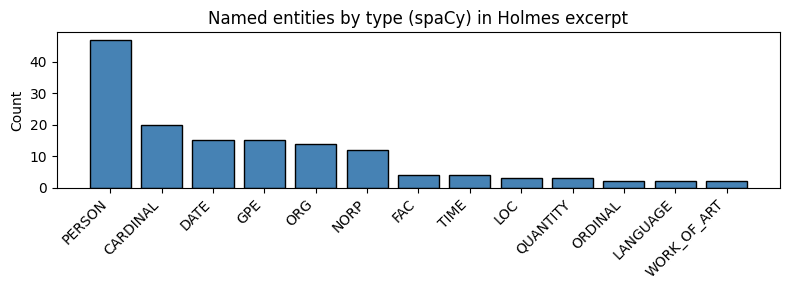

In [ ]:
type_counts = Counter(ent.label_ for ent in doc.ents)
labels_bar, counts_bar = zip(*type_counts.most_common())

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(labels_bar, counts_bar, color="steelblue", edgecolor="black")
ax.set_ylabel("Count")
ax.set_title("Named entities by type (spaCy) in Holmes excerpt")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Regex: dates

**Why it matters:** NER finds some dates, but regex lets us target exact formats—e.g. "March 20th, 1888" or numeric "3/20/1888"—which is useful for normalizing and parsing.

We use two patterns: one for month name + optional ordinal + year (e.g. "March 20th, 1888"), one for "ordinal of Month, year" (e.g. "twentieth of March, 1888"), and one for numeric `MM/DD/YYYY`.

In [ ]:
months = r"(January|February|March|April|May|June|July|August|September|October|November|December)"
date_long = re.findall(
    rf"\b{months}\s+\w+(?:st|nd|rd|th)?,?\s*(\d{{4}})\b",
    text,
    re.IGNORECASE,
)
date_ordinal_of = re.findall(
    rf"\b(\w+)\s+of\s+{months},?\s*(\d{{4}})\b",
    text,
    re.IGNORECASE,
)
print("Long-form dates (Month DD, YYYY):", date_long)
print("Ordinal of Month, YYYY:", date_ordinal_of)

date_numeric = re.findall(r"\b\d{1,2}/\d{1,2}/\d{4}\b", text)
print("Numeric dates:", date_numeric)

Long-form dates (Month DD, YYYY): []
Ordinal of Month, YYYY: [('twentieth', 'March', '1888')]
Numeric dates: []


## Regex: addresses

**Why it matters:** Addresses follow syntactic patterns (number + street name + type). Regex can pull them out even when NER doesn't tag them as a single span.

We look for a number (optionally with a letter, e.g. 221B) followed by words and a street-type keyword.

In [ ]:
addresses = re.findall(
    r"\b(\d+[A-Za-z]?\s+[\w\s]+(?:Street|Street,|Lane|Road|Avenue))\b",
    text,
)
print("Address-like:", addresses)

Address-like: []


## Regex: times

**Why it matters:** Expressions like "quarter to eight" or "half-past eleven" are easy to match with a small set of patterns and complement date extraction for a timeline.

In [ ]:
times = re.findall(
    r"\b(quarter\s+(?:past|to)\s+\w+|\d+\s*o\'?clock|half[- ]?past\s+\w+)\b",
    text,
    re.IGNORECASE,
)
print("Times:", times)

Times: ['quarter to eight']


## Combine: cast list and timeline

We bring together the extracted entities and regex results into a simple "cast" (people and places) and a short timeline (dates and times). This is the kind of structured summary you might feed into a database or dashboard.

In [ ]:
people = sorted(set(ent.text for ent in doc.ents if ent.label_ == "PERSON"))
places = sorted(set(ent.text for ent in doc.ents if ent.label_ in ("GPE", "LOC", "ORG")))
print("Cast (people):", people[:15])
print("Places/orgs:", places[:10])

timeline = []
timeline.extend([f"Date: {m[0]} {m[1]}" for m in date_long])
timeline.extend([f"Date: {m[1]} {m[2]} ({m[0]})" for m in date_ordinal_of])
timeline.extend([f"Time: {t}" for t in times])
print("Timeline:", timeline)

Cast (people): ['Atkinson', 'Bohemia', 'Holmes', 'Irene\nAdler', 'Irene Adler', 'La Scala', 'Langham', 'Majesty', 'Mary\nJane', 'Odessa', 'Stolen', 'Trepoff', 'Von Kramm', 'Wallenstein', 'Watson']
Places/orgs: ['Bohemia', 'Boswell', 'Carlsbad', 'Cassel-Felstein', 'Continental Gazetteer', 'Contralto', 'Eglonitz', 'Egria', 'England', 'Europe']
Timeline: ['Date: March 1888 (twentieth)', 'Time: quarter to eight']


## Clinical Text

Apply the same extraction techniques to clinical examples.

**POS tagging → symptom and finding extraction:**

In [ ]:
# Same technique: extract nouns to find clinical concepts
clinical_note = "Patient presents with severe headache, nausea, and photophobia. Denies fever or neck stiffness."

tokens = nltk.word_tokenize(clinical_note)
tagged = nltk.pos_tag(tokens)
clinical_nouns = [w for w, t in tagged if t.startswith("NN")]
print("Clinical nouns (potential symptoms/findings):", clinical_nouns)
# ['Patient', 'headache', 'nausea', 'photophobia', 'fever', 'neck', 'stiffness']

Clinical nouns (potential symptoms/findings): ['presents', 'headache', 'nausea', 'photophobia', 'Denies', 'fever', 'neck', 'stiffness']


Note: POS tagging finds *candidates*, but "fever" here is actually negated ("Denies fever"). You need additional logic—or specialized tools—to handle negation.

**NER: general models vs clinical models:**

In [ ]:
# General spaCy model on clinical text
clinical_text = "Dr. Chen at UCSF prescribed Lisinopril 10mg for hypertension on 03/15/2024."
doc = nlp(clinical_text)

print("General spaCy NER:")
for ent in doc.ents:
    print(f"  {ent.text}: {ent.label_}")
# Dr. Chen: PERSON, UCSF: ORG, 03/15/2024: DATE
# But Lisinopril and hypertension? Not recognized as entities.

General spaCy NER:
  Chen: PERSON
  UCSF: ORG
  Lisinopril 10: LAW
  03/15/2024: DATE


General NER models recognize people, organizations, and dates—but miss medications, diagnoses, and dosages. For clinical text, use **domain-specific models**:

| Model | Install | Recognizes |
| ----- | ------- | ---------- |
| **scispaCy** | `pip install scispacy` + model (see [scispaCy docs](https://allenai.github.io/scispacy/)) | Biomedical entities (genes, chemicals, diseases) |
| **MedSpaCy** | `pip install medspacy` | Clinical concepts + negation + section detection |

In [ ]:
# Example with scispaCy (if installed):
# import scispacy
# import spacy
# nlp_sci = spacy.load("en_core_sci_md")
# doc = nlp_sci("Lisinopril 10mg for hypertension")
# # Now "Lisinopril" and "hypertension" are recognized as entities

**Regex: clinical patterns instead of literary ones:**

In [ ]:
clinical_note = """
VS: BP 142/88, HR 76, RR 16, T 98.6°F, SpO2 98% RA
Meds: Metformin 500mg BID, Lisinopril 10mg daily, ASA 81mg
Labs: HbA1c 7.2%, Cr 1.1, K 4.2
"""

# Blood pressure (systolic/diastolic)
bp_pattern = r'\b(\d{2,3})/(\d{2,3})\b'
bp_matches = re.findall(bp_pattern, clinical_note)
print("Blood pressure:", [f"{s}/{d}" for s, d in bp_matches])

# Medications with dosages
med_pattern = r'(\b[A-Z][a-z]+(?:\s+[A-Z][a-z]+)?)\s+(\d+)\s*(mg|mcg|ml|units?)\b'
meds = re.findall(med_pattern, clinical_note, re.IGNORECASE)
print("Medications:", [(name, dose, unit) for name, dose, unit in meds])

# Lab values (name: value with optional unit)
lab_pattern = r'(\b[A-Z][A-Za-z0-9]+)\s+(\d+\.?\d*)\s*(%|mg/dL|mEq/L)?'
labs = re.findall(lab_pattern, clinical_note)
print("Labs:", [(name, val, unit) for name, val, unit in labs if name not in ['BP', 'HR', 'RR', 'SpO2']])

Blood pressure: ['142/88']
Medications: [('Metformin', '500', 'mg'), ('Lisinopril', '10', 'mg'), ('ASA', '81', 'mg')]
Labs: [('Metformin', '500', ''), ('Lisinopril', '10', ''), ('ASA', '81', ''), ('HbA1c', '7.2', '%'), ('Cr', '1.1', '')]


Just like we built a cast list and timeline from Holmes, clinical NLP builds structured data from unstructured notes. The difference is the domain-specific patterns and the additional complexity (negation, uncertainty, temporality) that clinical text requires.